Basic import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file upload

In [36]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


load dataset

In [37]:
dataset = pd.read_csv('dataset.csv')
dataset.head()

,Age,Height
0,10,138
1,11,138
2,12,138
3,13,139
4,14,139


segregate

In [38]:
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

split

In [39]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=0)


Training Dataset using Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [41]:
y_pred = model.predict(x_test)

evaluation

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [43]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 6.210569106251944
MSE : 45.7317198126293
RMSE: 6.762523183888488
R²  : 0.8547153936823451


adjusted r squerd

In [44]:
n, p = x.shape

In [45]:
def adjusted_r2(r2, n_samples, n_features):
    """Adjusted R² = 1 - (1 - R²) * (n-1) / (n - p - 1)"""
    if n_samples - n_features - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)

In [46]:
adjr2 = adjusted_r2(r2, n_samples=len(y_test), n_features=p)

In [47]:
print("Adjusted-R²  :", adjr2)

Adjusted-R²  : 0.8435396547348332


plot

Text(0.5, 1.0, 'Prediction vs Actual')

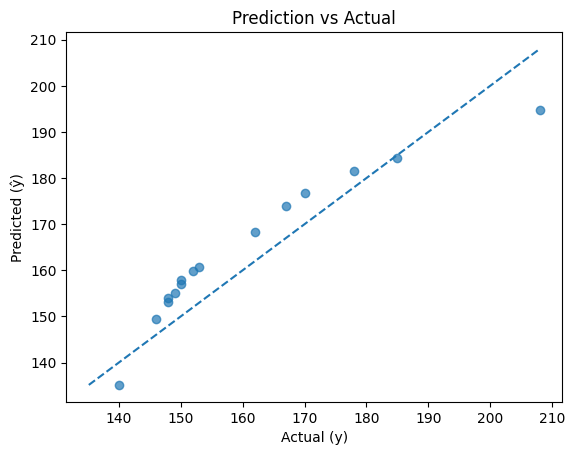

In [51]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, linestyle="--")  # perfect line
plt.xlabel("Actual (y)")
plt.ylabel("Predicted (ŷ)")
plt.title("Prediction vs Actual")

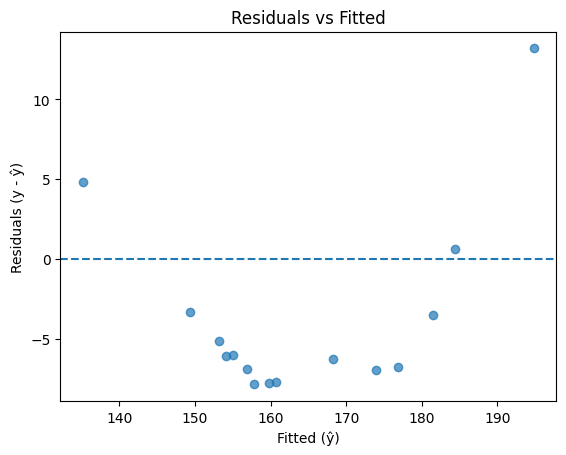

In [49]:
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted (ŷ)")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals vs Fitted")
plt.show()